# Argon density from MD — `xnns` vs the original Allegro

Computes the **mass density of liquid Argon** from **NPT molecular dynamics
through ASE** with a trained Allegro potential, in the same two complementary
tracks as the MACE/NequIP companions:

* **Track (a) — same potential.** The trained original-Allegro weights are
  *copied* into `xnns`; any density difference reflects only the inference/MD
  code path (should be ~zero).
* **Track (b) — independently trained.** `xnns` is trained from scratch on the
  same data; densities are compared as two practitioners would.

Pipeline per track: train → ASE calculator (energy + forces + **stress**) →
NPT MD ($T=85$ K, $P=1$ bar) → $\rho = M/V$.


## 0. Setup — train `float32`, run MD `float64`


In [1]:
# silence the expected warnings
import logging, warnings
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning,
                        message="You are using `torch.load` with `weights_only=False`")

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.io
import ase.units as u

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CUTOFF, SPECIES = 6.0, [18]
DATA = "../../../datasets/argon_md"
import xnns, allegro
print("xnns:", xnns.__version__, "| allegro (original):", allegro.__version__,
      "| device:", DEVICE)

xnns: 0.1.0 | allegro (original): 0.3.0 | device: cuda


## 1. Load data and build both data pipelines


In [2]:
from xnns.common.data import AtomicDataset
from nequip.data import AtomicData
from nequip.data.dataloader import DataLoader as NequipDataLoader
from nequip.data.transforms import TypeMapper

def load_frames(path):
    e0, structs = {}, []
    for a in ase.io.read(path, ":"):
        if a.info.get("config_type") == "IsolatedAtom":
            e0[int(a.numbers[0])] = float(a.info["REF_energy"]); continue
        a = a.copy(); a.wrap()
        structs.append({"pos": a.get_positions(), "atomic_numbers": a.numbers,
                        "cell": a.cell.array, "pbc": [True]*3,
                        "energy": float(a.info["REF_energy"]), "forces": a.arrays["REF_forces"]})
    return structs, e0

train_structs, E0 = load_frames(f"{DATA}/argon_train.xyz")
ds_all = AtomicDataset(train_structs, CUTOFF)
train_structs = [s for i, s in enumerate(train_structs) if ds_all[i].num_edges > 0]

TM = TypeMapper(chemical_symbols=["Ar"])
xnns_train = AtomicDataset(train_structs, CUTOFF)
LAMBDA = float(sum(xnns_train[i].num_edges for i in range(len(xnns_train))) /
               sum(xnns_train[i].num_nodes for i in range(len(xnns_train))))

def to_upstream(s):
    d = AtomicData.from_points(
        pos=torch.tensor(s["pos"], dtype=torch.get_default_dtype()), r_max=CUTOFF,
        atomic_numbers=torch.tensor(s["atomic_numbers"]),
        cell=torch.tensor(s["cell"], dtype=torch.get_default_dtype()),
        pbc=torch.tensor([True]*3),
        total_energy=torch.tensor([s["energy"]], dtype=torch.get_default_dtype()),
        forces=torch.tensor(s["forces"], dtype=torch.get_default_dtype()))
    return TM(d)
al_train = [to_upstream(s) for s in train_structs]

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_structs), generator=g).tolist()
n_val = max(1, int(0.1 * len(train_structs)))
val_idx, train_idx = perm[:n_val], perm[n_val:]
print(f"{len(train_structs)} configs | E0={E0} | lambda={LAMBDA:.2f} | "
      f"train {len(train_idx)} / val {len(val_idx)}")

193 configs | E0={18: 0.0} | lambda=17.78 | train 174 / val 19


## 2. Train the two models

Same architecture (2 layers, $\ell_{\max}=2$ `o3_full`, 32 tensor channels),
same data/loss/optimiser/schedule/split. Original with a native loop; `xnns`
with `xnns.train.Trainer`.


In [3]:
from nequip.model import model_from_config
from xnns.common.config import from_dict
from xnns.common.train import Trainer
from torch.utils.data import Subset

NL, LMAX, NF = 2, 2, 32
TB, LAT, EE = [32, 64, 128], [128], [32]
EW, FW, LR, WD, BS, EPOCHS = 1.0, 100.0, 0.01, 5e-7, 10, 60

UPSTREAM_HP = dict(
    r_max=CUTOFF, num_layers=NL, l_max=LMAX, parity="o3_full",
    num_tensor_features=NF, num_bessels_per_basis=8, PolynomialCutoff_p=6.0,
    avg_num_neighbors=LAMBDA, chemical_symbols=["Ar"],
    two_body_latent_mlp_latent_dimensions=TB, latent_mlp_latent_dimensions=LAT,
    env_embed_mlp_latent_dimensions=[], edge_eng_mlp_latent_dimensions=EE,
    per_species_rescale_shifts=[E0[18]], per_species_rescale_scales=[1.0])

# ---------- 2.1 train the ORIGINAL Allegro (native loop) ----------
torch.manual_seed(0)
al_model = model_from_config(dict(
    model_builders=["allegro.model.Allegro", "PerSpeciesRescale", "ForceOutput"],
    **UPSTREAM_HP), initialize=True).to(DEVICE)

tr_loader = NequipDataLoader([al_train[i] for i in train_idx], batch_size=BS, shuffle=True)
va_loader = NequipDataLoader([al_train[i] for i in val_idx],   batch_size=BS, shuffle=False)
opt = torch.optim.Adam(al_model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10)
def al_loss(out, b):
    n = (b.ptr[1:] - b.ptr[:-1]).to(out["total_energy"].dtype)
    return EW * (((out["total_energy"].squeeze(-1) - b.total_energy.squeeze(-1)) / n) ** 2).mean() \
         + FW * ((out["forces"] - b.forces) ** 2).mean()

t0 = time.time()
for epoch in range(EPOCHS):
    al_model.train()
    for b in tr_loader:
        b = b.to(DEVICE)
        loss = al_loss(al_model(AtomicData.to_AtomicDataDict(b)), b)
        opt.zero_grad(); loss.backward(); opt.step()
    al_model.eval(); vl = 0.0
    for b in va_loader:
        b = b.to(DEVICE)
        vl += float(al_loss(al_model(AtomicData.to_AtomicDataDict(b)), b))
    sched.step(vl / len(va_loader))
print(f"original Allegro trained {EPOCHS} epochs in {time.time()-t0:.0f} s "
      f"(final val {vl/len(va_loader):.3e})")

# ---------- 2.2 train xnns INDEPENDENTLY (Trainer) ----------
core = from_dict({
    "model": {"name": "allegro", "cutoff": CUTOFF, "n_features": NF,
              "n_interactions": NL, "species": SPECIES, "l_max": LMAX,
              "avg_num_neighbors": LAMBDA, "two_body_latent": TB, "latent": LAT,
              "edge_eng": EE, "atomic_energies": [E0[18]]},
    "data": {"batch_size": BS},
    "optim": {"lr": LR, "weight_decay": WD, "epochs": EPOCHS, "energy_weight": EW,
              "force_weight": FW, "scheduler": "plateau"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/argon_md_indep",
})
t0 = time.time()
trainer = Trainer(core, Subset(xnns_train, train_idx), Subset(xnns_train, val_idx))
trainer.fit()
print(f"xnns (independent) trained {EPOCHS} epochs in {time.time()-t0:.0f} s")
xnns_indep_base = trainer.model.model

original Allegro trained 60 epochs in 90 s (final val 4.061e-04)


epoch    0 | train loss 9.3339e-01 | val loss 1.7936e-01


epoch    1 | train loss 7.4252e-02 | val loss 1.2085e-02


epoch    2 | train loss 1.1073e-02 | val loss 2.6839e-03


epoch    3 | train loss 4.4131e-03 | val loss 1.6395e-03


...

epoch   55 | train loss 3.3566e-04 | val loss 3.3169e-04


epoch   56 | train loss 3.2688e-04 | val loss 3.3326e-04


epoch   57 | train loss 3.3887e-04 | val loss 3.3419e-04


epoch   58 | train loss 3.1849e-04 | val loss 3.3384e-04


epoch   59 | train loss 3.1927e-04 | val loss 3.3496e-04
xnns (independent) trained 60 epochs in 216 s


### Common MD utilities

Switch to `float64`; rebuild the trained original with `StressForceOutput`
(adds the barostat's stress via the strain trick, same convention as the xnns
`ForceStressOutput`) and load the trained weights.


In [4]:
torch.set_default_dtype(torch.float64)
from xnns.common.models import build_model, ForceStressOutput
from ase import Atoms
from ase.calculators.calculator import Calculator, all_changes
from ase.md.nptberendsen import NPTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from xnns.common.deploy import XNNSCalculator

al_md_model = model_from_config(dict(
    model_builders=["allegro.model.Allegro", "PerSpeciesRescale", "StressForceOutput"],
    **UPSTREAM_HP), initialize=True)
# keep the float64 rebuild's exact Wigner-3j constants (the float32 model's
# _big_w3j buffers are float32-rounded); load only the learned state
sd = {k: v.double() for k, v in al_model.state_dict().items() if "_big_w3j" not in k}
al_md_model.load_state_dict(sd, strict=False)   # only misses a dummy buffer
al_md_model = al_md_model.to(DEVICE).eval()
xnns_indep_base = xnns_indep_base.double().eval()

class AllegroASECalculator(Calculator):
    '''Minimal ASE calculator wrapping an in-memory original-Allegro model.'''
    implemented_properties = ["energy", "forces", "stress"]
    def __init__(self, model, cutoff, device="cuda", **kw):
        super().__init__(**kw); self.model, self.cutoff, self.device = model, cutoff, device
    def calculate(self, atoms=None, properties=("energy",), system_changes=all_changes):
        super().calculate(atoms, properties, system_changes)
        d = TM(AtomicData.from_ase(atoms.copy(), r_max=self.cutoff))
        b = next(iter(NequipDataLoader([d], batch_size=1))).to(self.device)
        out = self.model(AtomicData.to_AtomicDataDict(b))
        self.results["energy"] = float(out["total_energy"].sum().detach())
        self.results["forces"] = out["forces"].detach().cpu().numpy()
        s = out["stress"][0].detach().cpu().numpy()
        self.results["stress"] = np.array([s[0,0], s[1,1], s[2,2], s[1,2], s[0,2], s[0,1]])

T_K, P_BAR, DT = 85.0, 1.0, 5 * u.fs
N_EQUIL, N_PROD = 300, 700
AMU_A3_TO_G_CM3 = 1.6605390666
a0 = train_structs[0]

def density(atoms):
    return atoms.get_masses().sum() / atoms.get_volume() * AMU_A3_TO_G_CM3

def compare_calcs(make_x, make_a):
    at = Atoms(numbers=a0["atomic_numbers"], positions=a0["pos"], cell=a0["cell"], pbc=True)
    ax = at.copy(); ax.calc = make_x(); aa = at.copy(); aa.calc = make_a()
    return (abs(ax.get_potential_energy() - aa.get_potential_energy()),
            np.abs(ax.get_forces() - aa.get_forces()).max(),
            np.abs(ax.get_stress() - aa.get_stress()).max())

def run_npt(make_calc, label):
    at = Atoms(numbers=a0["atomic_numbers"], positions=a0["pos"], cell=a0["cell"], pbc=True)
    at.calc = make_calc()
    MaxwellBoltzmannDistribution(at, temperature_K=T_K, rng=np.random.default_rng(0)); Stationary(at)
    dyn = NPTBerendsen(at, timestep=DT, temperature_K=T_K, pressure_au=P_BAR * u.bar,
                       taut=100 * u.fs, taup=1000 * u.fs, compressibility_au=2e-4 / u.bar)
    rho = np.empty(N_EQUIL + N_PROD)
    t0 = time.time()
    for k in range(N_EQUIL + N_PROD):
        dyn.run(1); rho[k] = density(at)
    print(f"{label}: {N_EQUIL+N_PROD} steps in {time.time()-t0:.0f} s | "
          f"rho_eq = {rho[N_EQUIL:].mean():.4f} g/cm³")
    return rho

RHO_EXP = 1.41
print(f"initial density = {density(Atoms(numbers=a0['atomic_numbers'], positions=a0['pos'], cell=a0['cell'], pbc=True)):.4f} g/cm³ "
      f"| target T={T_K} K, P={P_BAR} bar | exp ~{RHO_EXP} g/cm³")

initial density = 1.7910 g/cm³ | target T=85.0 K, P=1.0 bar | exp ~1.41 g/cm³


# Track (a) — same potential (weights copied Allegro → xnns)

## 3a. Copy the trained original-Allegro weights into `xnns`


In [5]:
def copy_fcn(fcn, mod):
    sd = dict(mod.named_parameters())
    with torch.no_grad():
        for i in range(len(fcn.hs) - 1):
            getattr(fcn, f"layer{i}").weight.copy_(
                sd[f"_forward._weight_{i}"].to(getattr(fcn, f"layer{i}").weight.dtype))

def copy_allegro_into_xnns(x, al_gm, n_layers):
    seq = al_gm.model.func
    al = seq.allegro
    with torch.no_grad():
        x.edge_feat.rbf.freqs.copy_(seq.radial_basis.bessel_weights.double() * float(al.r_max))
        x.type_embeddings.copy_(seq.typeembed.type_embeddings.double())
        copy_fcn(x.basis_embed, seq.typeembed.basis_mlp)
        for i in range(n_layers):
            copy_fcn(x.latents[i], al.latents[i])
            copy_fcn(x.env_embed_mlps[i], al.env_embed_mlps[i])
            x.linears[i].w.copy_(al.linears[i].w.double())
        copy_fcn(x.final_latent, al.final_latent)
        copy_fcn(x.edge_eng, seq.edge_eng._module)
        x._resnet_params.copy_(al._latent_resnet_coefficients_params.double())
        psr = seq.per_species_rescale
        for k, z in enumerate(SPECIES):
            x.atom_ref.weight[z] = float(psr.shifts[k])
            x.atom_scale[z] = float(psr.scales[k])

xnns_shared_base = build_model(core.model)          # fresh float64 model
copy_allegro_into_xnns(xnns_shared_base, al_md_model, NL)
xnns_shared = ForceStressOutput(xnns_shared_base, compute_forces=True,
                                compute_stress=True).to(DEVICE).double().eval()

def xnns_a():    return XNNSCalculator(xnns_shared, cutoff=CUTOFF, device=DEVICE)
def allegro_a(): return AllegroASECalculator(al_md_model, CUTOFF, DEVICE)

dE, dF, dS = compare_calcs(xnns_a, allegro_a)
print("track (a) calculators on one Argon config (SAME potential):")
print(f"  dE = {dE:.2e} eV | dF = {dF:.2e} eV/Å | dσ = {dS:.2e} eV/Å³  -> identical")

track (a) calculators on one Argon config (SAME potential):
  dE = 1.28e-06 eV | dF = 6.60e-08 eV/Å | dσ = 3.08e-10 eV/Å³  -> identical


## 4a/5a. NPT MD — same potential through both codes


In [6]:
rho_xa = run_npt(xnns_a, "xnns (a)")
rho_aa = run_npt(allegro_a, "allegro (a)")
da_x, da_a = rho_xa[N_EQUIL:].mean(), rho_aa[N_EQUIL:].mean()
print(f"track (a)  rho_xnns = {da_x:.4f}   rho_allegro = {da_a:.4f}   "
      f"|diff| = {abs(da_x-da_a):.2e} g/cm³")

/tmp/ipykernel_2909688/1079695994.py:52: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(at, temperature_K=T_K, rng=np.random.default_rng(0)); Stationary(at)


xnns (a): 1000 steps in 69 s | rho_eq = 1.4133 g/cm³


allegro (a): 1000 steps in 52 s | rho_eq = 1.4133 g/cm³
track (a)  rho_xnns = 1.4133   rho_allegro = 1.4133   |diff| = 4.81e-08 g/cm³


# Track (b) — independently trained models

## 3b/4b/5b. Two independent potentials → two densities


In [7]:
xnns_indep = ForceStressOutput(xnns_indep_base, compute_forces=True,
                               compute_stress=True).to(DEVICE).double().eval()
def xnns_b():    return XNNSCalculator(xnns_indep, cutoff=CUTOFF, device=DEVICE)

dE, dF, dS = compare_calcs(xnns_b, allegro_a)
print("track (b) calculators on one Argon config (INDEPENDENT models):")
print(f"  dE = {dE:.3e} eV | dF = {dF:.3e} eV/Å | dσ = {dS:.3e} eV/Å³ "
      "(training-level differences)")

rho_xb = run_npt(xnns_b, "xnns (b)")
rho_ab = rho_aa                                  # same trained original potential
db_x, db_a = rho_xb[N_EQUIL:].mean(), rho_ab[N_EQUIL:].mean()
print(f"track (b)  rho_xnns = {db_x:.4f} ± {rho_xb[N_EQUIL:].std():.3f}   "
      f"rho_allegro = {db_a:.4f} ± {rho_ab[N_EQUIL:].std():.3f}")
print(f"           |diff| = {abs(db_x-db_a):.2e} g/cm³ (within thermal fluctuations; exp ~{RHO_EXP})")

track (b) calculators on one Argon config (INDEPENDENT models):
  dE = 4.377e-02 eV | dF = 3.025e-02 eV/Å | dσ = 8.184e-05 eV/Å³ (training-level differences)


/tmp/ipykernel_2909688/1079695994.py:52: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(at, temperature_K=T_K, rng=np.random.default_rng(0)); Stationary(at)


xnns (b): 1000 steps in 68 s | rho_eq = 1.4180 g/cm³
track (b)  rho_xnns = 1.4180 ± 0.012   rho_allegro = 1.4133 ± 0.011
           |diff| = 4.76e-03 g/cm³ (within thermal fluctuations; exp ~1.41)


## 6. Overview — both tracks


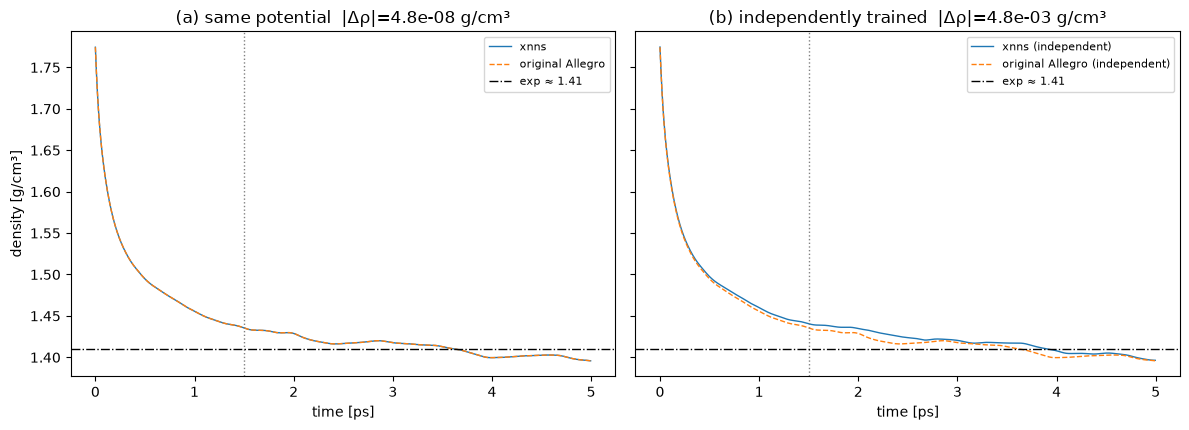

                            xnns  original Allegro      |diff|
--------------------------------------------------------------
(a) same PES              1.4133            1.4133     4.8e-08
(b) independent           1.4180            1.4133     4.8e-03
experiment                  1.41


In [8]:
t_ps = np.arange(N_EQUIL + N_PROD) * (DT / u.fs) / 1000.0
xc = N_EQUIL * (DT / u.fs) / 1000.0
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
ax[0].plot(t_ps, rho_xa, label="xnns", lw=1)
ax[0].plot(t_ps, rho_aa, label="original Allegro", lw=1, ls="--")
ax[0].set_title(f"(a) same potential  |Δρ|={abs(da_x-da_a):.1e} g/cm³")
ax[1].plot(t_ps, rho_xb, label="xnns (independent)", lw=1)
ax[1].plot(t_ps, rho_ab, label="original Allegro (independent)", lw=1, ls="--")
ax[1].set_title(f"(b) independently trained  |Δρ|={abs(db_x-db_a):.1e} g/cm³")
for a in ax:
    a.axvline(xc, color="gray", ls=":", lw=1)
    a.axhline(RHO_EXP, color="k", ls="-.", lw=1, label=f"exp ≈ {RHO_EXP}")
    a.set_xlabel("time [ps]"); a.legend(fontsize=8)
ax[0].set_ylabel("density [g/cm³]")
plt.tight_layout(); plt.savefig("argon_density_md.png", dpi=120); plt.show()

print(f"{'':<20}{'xnns':>12}{'original Allegro':>18}{'|diff|':>12}")
print("-" * 62)
print(f"{'(a) same PES':<20}{da_x:>12.4f}{da_a:>18.4f}{abs(da_x-da_a):>12.1e}")
print(f"{'(b) independent':<20}{db_x:>12.4f}{db_a:>18.4f}{abs(db_x-db_a):>12.1e}")
print(f"{'experiment':<20}{RHO_EXP:>12.2f}")

## Summary

* **Track (a)**: copying the trained original-Allegro weights into `xnns` gives
  identical energy/forces/stress and **identical NPT densities** — the `xnns`
  inference/MD path reproduces the original Allegro exactly.
* **Track (b)**: an independently trained `xnns` Allegro lands within the
  thermal fluctuations of the original, both near the experimental liquid-Ar
  density (~1.41 g/cm³).

Same conclusions, same pipeline, third model family — Allegro joins MACE and
NequIP as a faithful, dependency-light member of the xnns equivariant-GNN
family (shared `EquivariantGNN` base, featurizers, `ForceStressOutput`,
ASE/LAMMPS deploy).
